# AstroCLIP Checkpoint Loader and Embedding Generator

In [1]:
# # Base install of required utilities
# !apt install python3-dev libcairo2-dev pkg-config

# # Setting up proper torch version
# !pip install --upgrade pip
# !pip install lightning[extra]==2.3.3 boto3==1.28.17
# !pip install --upgrade pycairo datasets pyarrow
# !pip install --extra-index-url https://pypi.nvidia.com cuml-cu11
# !pip install --extra-index-url https://download.pytorch.org/whl/cu117 torch==2.0.0+cu117
# !pip install torchvision==0.15.0 torchmetrics==0.10.3 dotenv
# !pip install numpy==1.26.4 --force-reinstall

# # Installing DiNOv2
# !pip install omegaconf fvcore iopath
# !pip install --no-deps git+https://github.com/facebookresearch/dinov2.git@2302b6bf46953431b969155307b9bed152754069

# # Installing AstroCLIP
# !pip install astropy datasets huggingface_hub jaxtyping wandb networkx pyvis
# !pip uninstall -y transformers
# !pip install --no-deps git+https://github.com/PolymathicAI/AstroCLIP.git

In [2]:
# # Restarting kernel after everything is installed
# import os

# os.kill(os.getpid(), 9)

In [3]:
# # Downloading model weights
# !wget -O astrodino.ckpt https://huggingface.co/polymathic-ai/astrodino/resolve/main/astrodino.ckpt?download=true

## Load Data

In [1]:
import datasets
import torch
from astroclip.data.datamodule import AstroClipCollator
from datasets import load_dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np 

/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [2]:
# @title [Run me]
%pylab inline
import pyarrow

pyarrow.PyExtensionType.set_auto_load(True)
import base64
from io import BytesIO

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from IPython.display import HTML, display
from ipywidgets import interact
from pyvis.network import Network
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import normalize
from tqdm import tqdm


def graph_from_embeddings(embeddings, images, k=5, symmetrize=True):
    """
    Builds a k-NN graph adjacency matrix using scikit-learn (cosine distance).

    Returns a sparse adjacency matrix (numpy array or CSR).
    """
    # Convert to NumPy and normalize (cosine similarity = dot of L2-normalized vectors)
    emb_np = embeddings.cpu().numpy()

    # scikit-learn uses cosine *distance*, so we negate similarity in behavior
    A = kneighbors_graph(
        emb_np, n_neighbors=k, metric="cosine", mode="connectivity", include_self=False
    )

    if symmetrize:
        A = A.maximum(A.T)  # make it symmetric (undirected)

    G = nx.Graph()
    A = A.tocoo()

    for i in range(A.shape[0]):
        G.add_node(
            i,
            image_tensor=(
                images[i].permute(1, 2, 0).cpu().numpy() if images is not None else None
            ),
        )

    for i, j, w in zip(A.row, A.col, A.data):
        G.add_edge(i, j, weight=w)

    return G


def encode_image_base64(image_array, scale=1.0):
    fig = plt.figure(figsize=(scale, scale), dpi=100)
    plt.axis("off")
    plt.imshow(image_array)
    buf = BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    buf.seek(0)
    img_base64 = base64.b64encode(buf.read()).decode("utf-8")
    return f"data:image/png;base64,{img_base64}"


def draw_interactive_graph_colab(graph):
    net = Network(
        height="750px",
        width="100%",
        bgcolor="#000000",
        font_color="white",
        notebook=False,
        cdn_resources="remote",
    )

    # Encode each image as base64 and use as node icon
    for node_id, data in graph.nodes(data=True):
        img_url = encode_image_base64(data["image_tensor"])
        net.add_node(
            int(node_id),
            shape="image",
            image=img_url,
            title=f"Galaxy {node_id}",
            size=50,
        )

    for src, tgt, data in graph.edges(data=True):
        net.add_edge(
            int(src),
            int(tgt),
            value=float(data["weight"]) * 5,
            color="rgba(255, 255, 255, 0.5)",
        )

    # Generate the HTML string (without writing to file)
    html_str = net.generate_html()

    # Display directly in Colab
    return HTML(html_str)

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
# Loads cross-matched data between DESI and Legacy Survey images
dataset_path = "/pbs/throng/training/astroinfo2025/data/astroPT_euclid_desi_dataset/data/"
dset = load_dataset(dataset_path, streaming=True, split="train")
dset = dset.with_format("torch")

# Creates a torch data loader for the data
dloader = DataLoader(
    dset, batch_size=256, collate_fn=AstroClipCollator(), drop_last=True
)
iter_dset = iter(dloader.dataset)

# We can extract one bach of objects like so:
batch = next(iter_dset)

print(batch.keys())

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

dict_keys(['object_id', 'targetid', 'redshift', 'RGB_image', 'VIS_image', 'NISP_Y_image', 'NISP_J_image', 'NISP_H_image', 'sed_data', 'spectrum'])


In [4]:
import numpy as np
from collections import defaultdict

# Initialize a dictionary with lists for each key
stacked = defaultdict(list)

for i, b in enumerate(iter_dset):
    if i >= 5000:
        break
    #print(i)
    for key, value in b.items():
        stacked[key].append(value)

# Convert lists to arrays (if possible)
stacked_arrays = {k: np.array(v) for k, v in stacked.items()}

# Example: check keys and shapes
for k, v in stacked_arrays.items():
    print(k, v.shape)


object_id (5000,)
targetid (5000,)
redshift (5000,)
RGB_image (5000, 3, 224, 224)
VIS_image (5000, 224, 224)
NISP_Y_image (5000, 224, 224)
NISP_J_image (5000, 224, 224)
NISP_H_image (5000, 224, 224)
sed_data (5000,)
spectrum (5000,)


In [5]:
import torch

# Convert all NumPy arrays in stacked_arrays to torch tensors
stacked_tensors = {}
for k, v in stacked_arrays.items():
    try: tensor = torch.tensor(v, dtype=torch.float32)  # convert to float32
    except: continue
    # If the tensor is 3D (batch, H, W), add a channel dimension
    if tensor.ndim == 3:
        tensor = tensor.unsqueeze(1)  # adds channels=1 -> (batch, 1, H, W)

    stacked_tensors[k] = tensor

# Move all tensors to GPU if needed
for k in stacked_tensors:
    stacked_tensors[k] = stacked_tensors[k].to("cuda")

print(stacked_tensors['VIS_image'].shape)

torch.Size([5000, 1, 224, 224])


In [6]:
# Before normalization
for band in ['VIS_image', 'NISP_Y_image', 'NISP_J_image', 'NISP_H_image', 'RGB_image']:
    
    images = stacked_tensors[band].detach().cpu()  # copy to CPU

    # If RGB_image, make sure it's in [0,1]
    if band == 'RGB_image':
        if images.max() > 1.0:
            images = images / 255.0

    # Ensure tensor is (B, C, H, W)
    if images.ndim == 3:  # (B, H, W)
        images = images[:, None, :, :]  # add channel dim

#    fig, axes = plt.subplots(8, 8, figsize=(20, 20))
#    axes = axes.flatten()

#    for i in range(64):
#        img = images[i]
#        # Convert to HWC for imshow if multi-channel
#        if img.shape[0] == 1:
#            img_to_plot = img[0]
#        else:
#            img_to_plot = np.transpose(img, (1, 2, 0))

#        axes[i].imshow(img_to_plot)
#        axes[i].set_title(stacked_tensors['object_id'][i])
#        axes[i].axis("off")

#    fig.suptitle(f"{band} [Before normalization]", fontsize=30)
#    fig.tight_layout(rect=[0, 0, 1, 0.96])
#    plt.show()


## Old Preprocessing 

In [7]:
import torch
import torch.nn.functional as F

# ----------------------------
# Parameters
# ----------------------------
patch_size = 12
image_bands = ['VIS_image', 'NISP_Y_image', 'NISP_J_image', 'NISP_H_image']

# ----------------------------
# 1️⃣ Resize all image tensors to multiples of patch_size
# ----------------------------
H, W = stacked_tensors['RGB_image'].shape[2], stacked_tensors['RGB_image'].shape[3]
new_H = (H // patch_size) * patch_size
new_W = (W // patch_size) * patch_size

print(f"[INFO] Resizing from ({H}, {W}) → ({new_H}, {new_W})")

for key in list(stacked_tensors.keys()):
    tensor = stacked_tensors[key]
    if tensor.ndim == 4:  # Expect (B, C, H, W)
        stacked_tensors[key] = F.interpolate(
            tensor,
            size=(new_H, new_W),
            mode='bilinear',
            align_corners=False
        )
        print(f"[OK] {key} resized to {stacked_tensors[key].shape}")
    else:
        print(f"[SKIP] {key}: ndim={tensor.ndim}")

# ----------------------------
# 2️⃣ Handle NaNs and Infs
# ----------------------------
for key, tensor in stacked_tensors.items():
    if key == "object_id":
        continue
    if torch.isnan(tensor).any():
        mean_val = tensor[~torch.isnan(tensor)].mean() if (~torch.isnan(tensor)).any() else 0.0
        tensor[torch.isnan(tensor)] = mean_val
    if torch.isinf(tensor).any():
        tensor[torch.isinf(tensor)] = 0.0
    stacked_tensors[key] = tensor

# ----------------------------
# 3️⃣ Per-band normalization to [0,1]
# ----------------------------
for key in image_bands:
    tensor = stacked_tensors[key]
    band_min = tensor.min()
    band_max = tensor.max()
    stacked_tensors[key] = (tensor - band_min) / (band_max - band_min + 1e-8)
    print(f"[OK] {key} normalized: min={stacked_tensors[key].min():.3f}, max={stacked_tensors[key].max():.3f}")

# ----------------------------
# 4️⃣ Create RGB image from VIS_image
# ----------------------------
vis = stacked_tensors['VIS_image']  # (B, C, H, W) or (B, 1, H, W)
# If single channel, make 3 copies
if vis.shape[1] == 1:
    rgb_image = torch.cat([vis, vis, vis], dim=1)  # (B, 3, H, W)
else:
    rgb_image = vis[:, :3]  # keep first 3 channels if already 3+
stacked_tensors['RGB_image'] = rgb_image
print(f"[OK] RGB_image created: {rgb_image.shape}")

# ----------------------------
# 5️⃣ Clamp all images to [0,1] as a safety
# ----------------------------
for key in image_bands + ['RGB_image']:
    stacked_tensors[key] = stacked_tensors[key].clamp(0,1)
    print(f"[OK] {key} normalized: min={stacked_tensors[key].min():.3f}, max={stacked_tensors[key].max():.3f}")


[INFO] Resizing from (224, 224) → (216, 216)
[SKIP] object_id: ndim=1
[SKIP] targetid: ndim=1
[SKIP] redshift: ndim=1
[OK] RGB_image resized to torch.Size([5000, 3, 216, 216])
[OK] VIS_image resized to torch.Size([5000, 1, 216, 216])
[OK] NISP_Y_image resized to torch.Size([5000, 1, 216, 216])
[OK] NISP_J_image resized to torch.Size([5000, 1, 216, 216])
[OK] NISP_H_image resized to torch.Size([5000, 1, 216, 216])
[OK] VIS_image normalized: min=0.000, max=1.000
[OK] NISP_Y_image normalized: min=0.000, max=1.000
[OK] NISP_J_image normalized: min=0.000, max=1.000
[OK] NISP_H_image normalized: min=0.000, max=1.000
[OK] RGB_image created: torch.Size([5000, 3, 216, 216])
[OK] VIS_image normalized: min=0.000, max=1.000
[OK] NISP_Y_image normalized: min=0.000, max=1.000
[OK] NISP_J_image normalized: min=0.000, max=1.000
[OK] NISP_H_image normalized: min=0.000, max=1.000
[OK] RGB_image normalized: min=0.000, max=1.000


## New preprocessing

[INFO] Resizing from (224, 224) → (216, 216)
[SKIP] object_id: ndim=1
[SKIP] targetid: ndim=1
[SKIP] redshift: ndim=1
[OK] RGB_image resized to torch.Size([5000, 3, 216, 216])
[OK] VIS_image resized to torch.Size([5000, 1, 216, 216])
[OK] NISP_Y_image resized to torch.Size([5000, 1, 216, 216])
[OK] NISP_J_image resized to torch.Size([5000, 1, 216, 216])
[OK] NISP_H_image resized to torch.Size([5000, 1, 216, 216])
[OK] Legacy reference image loaded: (152, 152, 3)
[OK] RGB_image histogram-matched and updated: torch.Size([5000, 3, 216, 216])
[OK] VIS_image histogram-matched and updated: torch.Size([5000, 1, 216, 216])
[OK] NISP_Y_image histogram-matched and updated: torch.Size([5000, 1, 216, 216])
[OK] NISP_J_image histogram-matched and updated: torch.Size([5000, 1, 216, 216])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.032940466..0.78933114].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010226579..0.78933114].


[OK] NISP_H_image histogram-matched and updated: torch.Size([5000, 1, 216, 216])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.032940466..0.78933114].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.032940466..0.78933114].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.032940466..0.78933114].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.032940466..0.78933114].


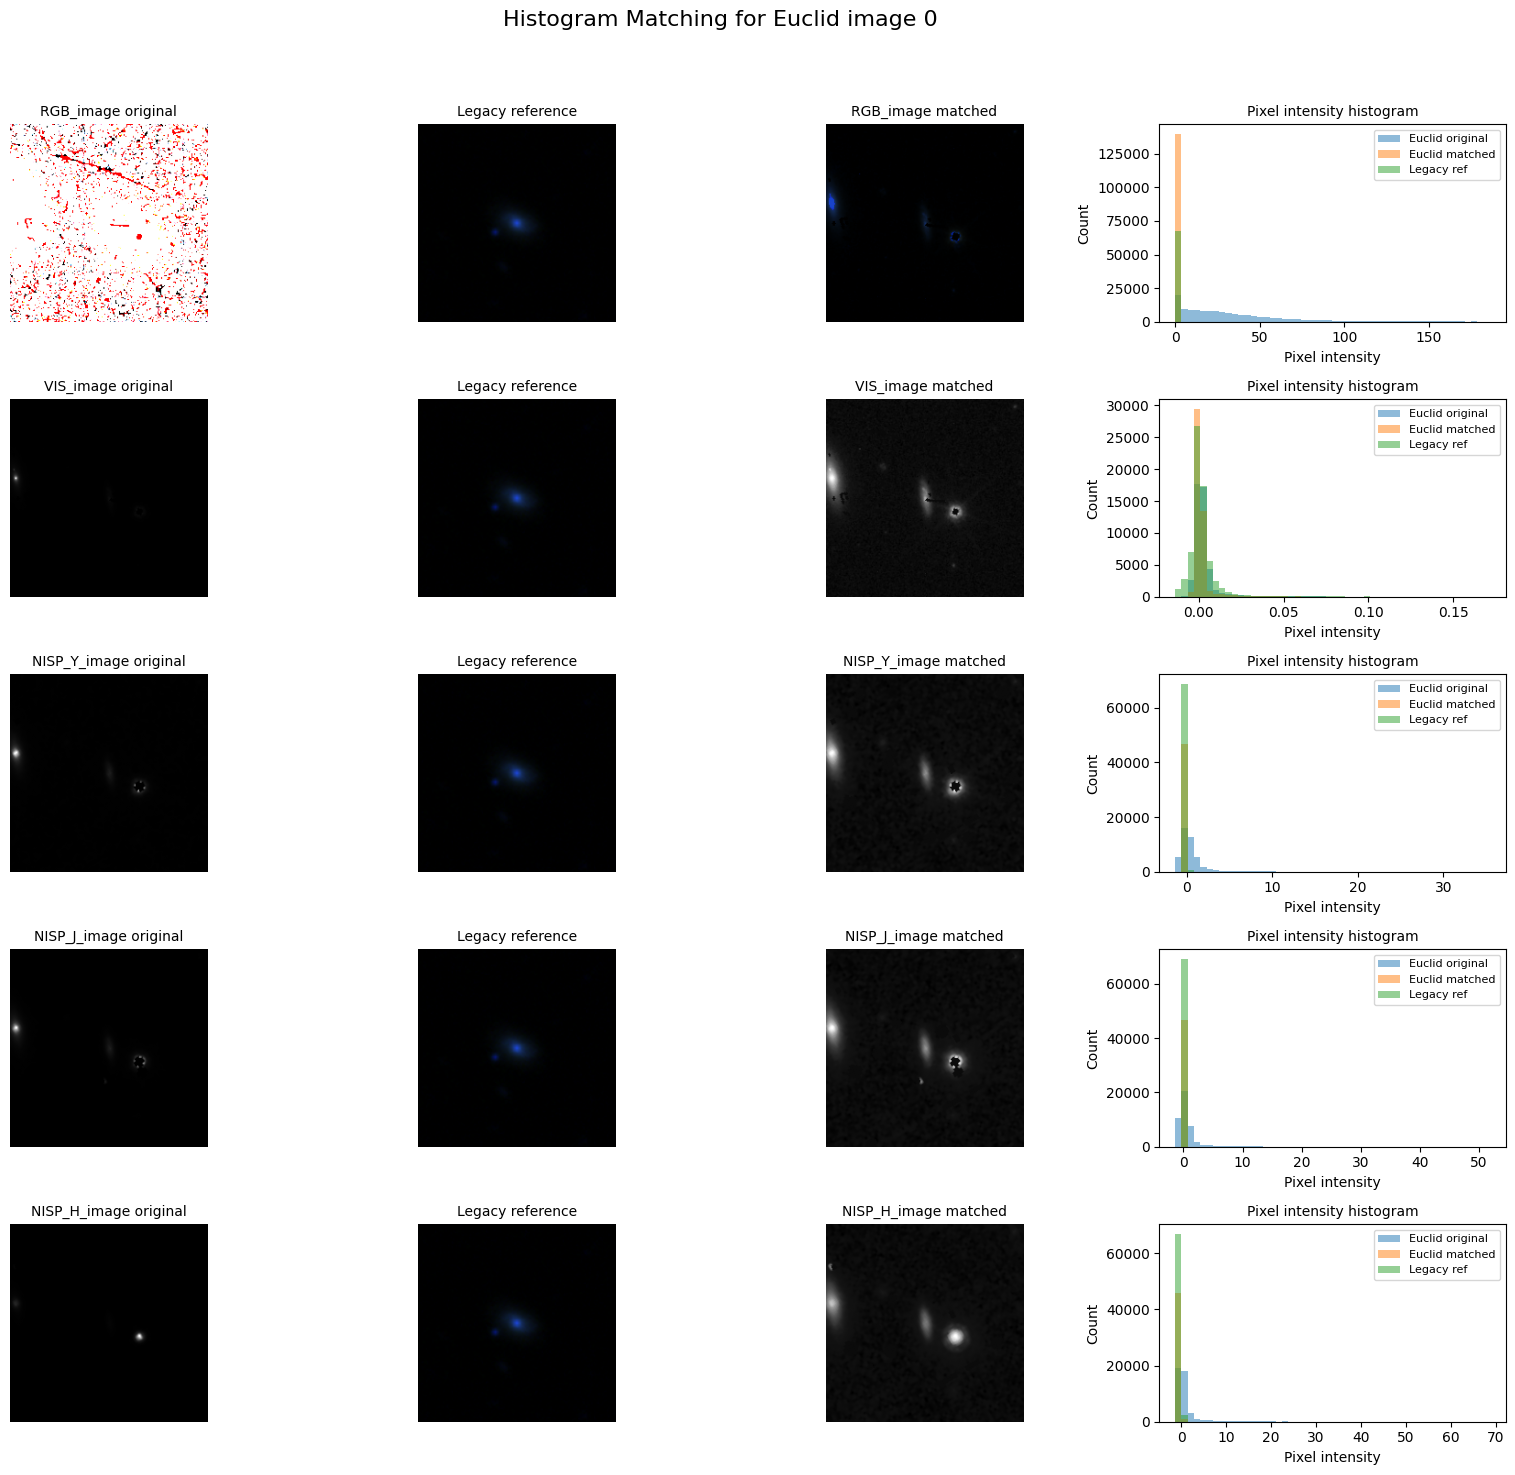

In [7]:
import torch
import torch.nn.functional as F

# ----------------------------
# Parameters
# ----------------------------
patch_size = 12
image_bands = ['VIS_image', 'NISP_Y_image', 'NISP_J_image', 'NISP_H_image']

# ----------------------------
# 1️⃣ Resize all image tensors to multiples of patch_size
# ----------------------------
H, W = stacked_tensors['RGB_image'].shape[2], stacked_tensors['RGB_image'].shape[3]
new_H = (H // patch_size) * patch_size
new_W = (W // patch_size) * patch_size

print(f"[INFO] Resizing from ({H}, {W}) → ({new_H}, {new_W})")

for key in list(stacked_tensors.keys()):
    tensor = stacked_tensors[key]
    if tensor.ndim == 4:  # Expect (B, C, H, W)
        stacked_tensors[key] = F.interpolate(
            tensor,
            size=(new_H, new_W),
            mode='bilinear',
            align_corners=False
        )
        print(f"[OK] {key} resized to {stacked_tensors[key].shape}")
    else:
        print(f"[SKIP] {key}: ndim={tensor.ndim}")

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms
import fsspec
import h5py

# =============================
# Parameters
# =============================
euclid_bands = ['RGB_image', 'VIS_image', 'NISP_Y_image', 'NISP_J_image', 'NISP_H_image']
img_idx = 0
legacy_ref_idx = 0
legacy_image_dataset_url = "https://users.flatironinstitute.org/~flanusse/astroclip_desi.1.1.5.h5"

# =============================
# Stream single Legacy image
# =============================
with fsspec.open(legacy_image_dataset_url, "rb") as f:
    with h5py.File(f, "r") as h5f:
        collected = 0
        for grp_name in sorted(h5f.keys()):
            grp = h5f[grp_name]
            if legacy_ref_idx < len(grp['images']):
                legacy_ref = np.array(grp['images'][legacy_ref_idx])  # H,W,C
                break
            else:
                legacy_ref_idx -= len(grp['images'])
print(f"[OK] Legacy reference image loaded: {legacy_ref.shape}")

# =============================
# Save original Euclid images
# =============================
euclid_orig = {band: stacked_tensors[band].clone() for band in euclid_bands}

# =============================
# Histogram match all Euclid bands and update stacked_tensors
# =============================
for band in euclid_bands:
    tensor = stacked_tensors[band]  # (B,C,H,W)
    B, C, H, W = tensor.shape
    matched_list = []

    for b in range(B):
        img_euclid = tensor[b].detach().cpu().numpy()  # C,H,W
        img_euclid = np.transpose(img_euclid, (1,2,0))  # H,W,C

        if img_euclid.shape[2] == 1:
            img_matched = match_histograms(img_euclid[:,:,0], legacy_ref[:,:,0], channel_axis=None)
            img_matched = img_matched[..., np.newaxis]
        else:
            img_matched = match_histograms(img_euclid, legacy_ref, channel_axis=-1)

        matched_list.append(torch.from_numpy(np.transpose(img_matched, (2,0,1))))

    stacked_tensors[band] = torch.stack(matched_list, dim=0)
    print(f"[OK] {band} histogram-matched and updated: {stacked_tensors[band].shape}")

# =============================
# Plot first image for all bands
# =============================
fig, axes = plt.subplots(len(euclid_bands), 4, figsize=(16, len(euclid_bands)*3))

for i, band in enumerate(euclid_bands):
    # Column 0: original Euclid
    img_orig = np.transpose(euclid_orig[band][img_idx].detach().cpu().numpy(), (1,2,0))
    ax = axes[i,0]
    if img_orig.shape[2] == 1:
        ax.imshow(img_orig[:,:,0], cmap='gray')
    else:
        ax.imshow(img_orig)
    ax.set_title(f"{band} original", fontsize=10)
    ax.axis('off')

    # Column 1: Legacy reference
    ax = axes[i,1]
    ax.imshow(legacy_ref)
    ax.set_title("Legacy reference", fontsize=10)
    ax.axis('off')

    # Column 2: matched Euclid
    img_matched = np.transpose(stacked_tensors[band][img_idx].detach().cpu().numpy(), (1,2,0))
    ax = axes[i,2]
    if img_matched.shape[2] == 1:
        ax.imshow(img_matched[:,:,0], cmap='gray')
    else:
        ax.imshow(img_matched)
    ax.set_title(f"{band} matched", fontsize=10)
    ax.axis('off')

    # Column 3: histogram
    ax = axes[i,3]
    all_pixels = [
        img_orig.flatten(),
        img_matched.flatten(),
        legacy_ref.flatten()
    ]
    labels = ['Euclid original','Euclid matched','Legacy ref']
    vmin, vmax = np.percentile(np.concatenate(all_pixels), [0.5,99.5])
    for data,label in zip(all_pixels, labels):
        ax.hist(data, bins=50, alpha=0.5, label=label, range=(vmin,vmax))
    ax.set_xlabel("Pixel intensity")
    ax.set_ylabel("Count")
    ax.set_title("Pixel intensity histogram", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle(f"Histogram Matching for Euclid image {img_idx}", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [8]:
# After normalization
for band in ['VIS_image', 'NISP_Y_image', 'NISP_J_image', 'NISP_H_image', 'RGB_image']:
    
    images = stacked_tensors[band] * 1  # copy

    # Ensure tensor is on CPU for matplotlib
    images = images.detach().cpu()

    # Check if the tensor is (B, H, W) and add a dummy channel for imshow
    if images.ndim == 3:  # (B, H, W)
        images = images[:, None, :, :]  # (B, 1, H, W)

#    fig, axes = plt.subplots(8, 8, figsize=(20, 20))
#    axes = axes.flatten()

#    for i in range(64):
#        img = images[i]
        # Convert to HWC for imshow if single channel
#        if img.shape[0] == 1:
#            img_to_plot = img[0]
#        else:
            # If 3 channels, convert C,H,W -> H,W,C
#            img_to_plot = np.transpose(img, (1, 2, 0))
        
#        axes[i].imshow(img_to_plot)
#        axes[i].set_title(stacked_tensors['object_id'][i])
#        axes[i].axis("off")

#    fig.suptitle(f"{band} [After normalization]", fontsize=30)
#    fig.tight_layout(rect=[0, 0, 1, 0.96])
#    plt.show()


## ASTROCLIP CKPT

In [10]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import yaml
from astroclip.models.astroclip import ImageHead, AstroClipModel
from torch.utils.data import Dataset, DataLoader, random_split

# 1. Paths to the YAML config and checkpoint file (pretrained or fine-tuned)
#yaml_path = "/pbs/throng/training/astroinfo2025/data/AstroCLIP_team/AstroCLIP/astrodino_config.yaml"
checkpoint_path = "/pbs/throng/training/astroinfo2025/data/AstroCLIP_team/AstroCLIP/astroclip.ckpt"

model = AstroClipModel.load_from_checkpoint(
    checkpoint_path=checkpoint_path
).eval()

# 7. Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 8. Prepare the test dataset loader
# Assuming 'full_dataset' is your complete EuclidDataset instance as in your code

class EuclidDataset(Dataset):
    def __init__(self, stacked_tensors, bands=['RGB_image'], patch_size=12):
        self.bands = bands
        self.data = {}
        for k in bands:
            t = stacked_tensors[k]
            self.data[k] = t.cpu()  # force CPU to avoid CUDA init errors
        self.length = self.data[bands[0]].shape[0]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        img = torch.cat([self.data[b][idx] for b in self.bands], dim=0)
        return {"image": img}

full_dataset = EuclidDataset(stacked_tensors, patch_size=12)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

print(n_total)
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [n_train, n_val, n_test])

test_loader = DataLoader(train_dataset, batch_size=16, shuffle=False, num_workers=1, pin_memory=True)

# 9. Apply model to test dataset and collect embeddings
all_test_embeddings = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        imgs = batch["image"].to(device, non_blocking=True)
        embeddings = model(imgs, input_type="image")  # Forward pass for image input
        all_test_embeddings.append(embeddings.cpu())

test_embeddings = torch.cat(all_test_embeddings, dim=0)

print(f"Test set embeddings shape: {test_embeddings.shape}")

/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'image_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['image_encoder'])`.
/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:208: Attribute 'spectrum_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['spectrum_encoder'])`.


5000
Test set embeddings shape: torch.Size([4000, 1024])


## FINETUNED CKPT

In [ ]:
# =========================================================
# 1. Paths
# =========================================================
yaml_path = "/pbs/throng/training/astroinfo2025/data/AstroCLIP_team/AstroCLIP/astrodino_config.yaml"

# New fine-tuned checkpoint
euclid_refined_ckpt_path = "/pbs/throng/training/astroinfo2025/data/AstroCLIP_team/AstroCLIP/astrodino_euclid_RGB_10000_pre_process.ckpt"

# ----------------------------
# 3️⃣ Rebuild ImageHead from YAML
# ----------------------------

student_cfg = config["student"]
embed_dim = 1024
n_head = 4
model_embed_dim = 1024
dropout = 0.1
freeze_backbone = False

image_encoder_reloaded = ImageHead(
    config=yaml_path,
    model_weights=euclid_refined_ckpt_path,               # leave empty; we will load ckpt manually
    save_directory="/tmp/astroclip_temp",
    embed_dim=embed_dim,
    n_head=n_head,
    model_embed_dim=model_embed_dim,
    dropout=dropout,
    freeze_backbone=freeze_backbone
)

# ----------------------------
# 4️⃣ Load new euclid_refined_checkpoint weights
# ----------------------------
euclid_refined_checkpoint = torch.load(euclid_refined_ckpt_path, map_location="cpu")
print(euclid_refined_checkpoint.keys())
# Load only relevant keys into image_encoder_reloaded
image_encoder_reloaded.load_state_dict(euclid_refined_checkpoint["state_dict"], strict=False)
image_encoder_reloaded.eval()

# ----------------------------
# 5️⃣ Wrap in AstroClipModel (optional)
# ----------------------------
class DummySpectrum(torch.nn.Module):
    def forward(self, x):
        return torch.zeros(x.shape[0], 1024)

spectrum_encoder = DummySpectrum()

model_reloaded = AstroClipModel(
    image_encoder=image_encoder_reloaded,
    spectrum_encoder=spectrum_encoder,
)
model_reloaded.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_reloaded.to(device)

class EuclidDataset(Dataset):
    def __init__(self, stacked_tensors, bands=['RGB_image'], patch_size=12):
        self.bands = bands
        self.data = {}
        for k in bands:
            t = stacked_tensors[k]
            self.data[k] = t.cpu()  # force CPU to avoid CUDA init errors
        self.length = self.data[bands[0]].shape[0]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        img = torch.cat([self.data[b][idx] for b in self.bands], dim=0)
        return {"image": img}

full_dataset = EuclidDataset(stacked_tensors, patch_size=12)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

print(n_total)
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [n_train, n_val, n_test])

test_loader = DataLoader(train_dataset, batch_size=16, shuffle=False, num_workers=1, pin_memory=True)

# 9. Apply model to test dataset and collect embeddings
all_test_embeddings = []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        imgs = batch["image"].to(device, non_blocking=True)
        embeddings = model(imgs, input_type="image")  # Forward pass for image input
        all_test_embeddings.append(embeddings.cpu())

test_embeddings = torch.cat(all_test_embeddings, dim=0)

print(f"Test set embeddings shape: {test_embeddings.shape}")


## PCA Analysis

Mean embedding norm : 11.0695
Std of embedding norm: 0.0017
Global mean: 5.3082e-03, std: 3.4589e-01
Avg cosine similarity (including self): 1.0000
Avg cosine similarity (excluding self): 0.9998


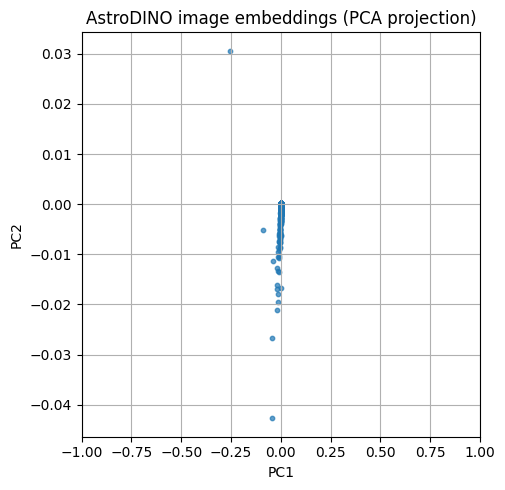

In [11]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
import yaml
from astroclip.models.astroclip import ImageHead, AstroClipModel

# ----------------------------
# 1️⃣ Basic stats
# ----------------------------
mean_norm = test_embeddings.norm(dim=1).mean().item()
std_norm = test_embeddings.norm(dim=1).std().item()
print(f"Mean embedding norm : {mean_norm:.4f}")
print(f"Std of embedding norm: {std_norm:.4f}")
print(f"Global mean: {test_embeddings.mean().item():.4e}, std: {embeddings.std().item():.4e}")

# ----------------------------
# 2️⃣ Diversity check via cosine similarity
# ----------------------------
emb_norm = F.normalize(test_embeddings, dim=1)
cosine_sim = emb_norm @ emb_norm.T
avg_sim = cosine_sim.mean().item()
diag_mean = cosine_sim.diag().mean().item()
print(f"Avg cosine similarity (including self): {avg_sim:.4f}")
print(f"Avg cosine similarity (excluding self): {((cosine_sim.sum() - cosine_sim.trace()) / (cosine_sim.numel() - len(embeddings))).item():.4f}")

# ----------------------------
# 3️⃣ Quick PCA visualization
# ----------------------------
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(test_embeddings.cpu().numpy())

plt.figure(figsize=(5,5))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=10, alpha=0.7)
plt.title("AstroDINO image embeddings (PCA projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.xlim(-1,1)
plt.show()
plt.close()



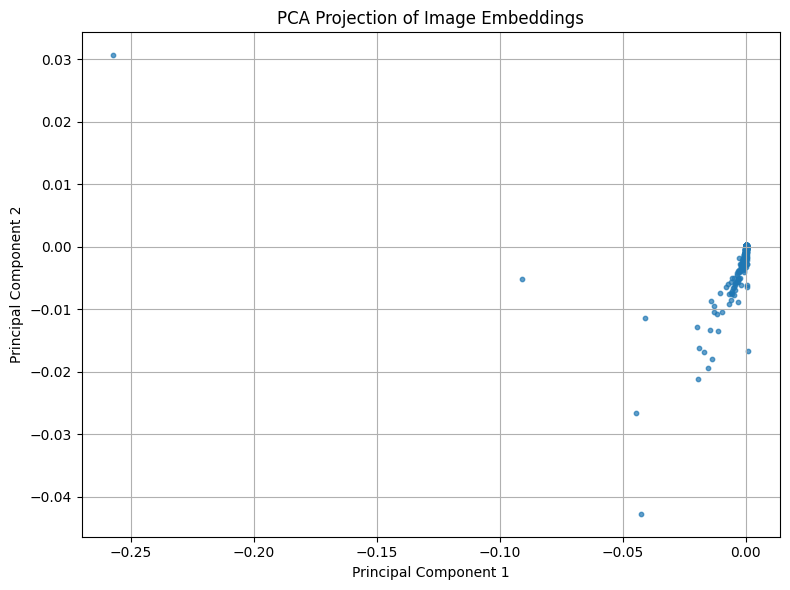

In [12]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming `embeddings` tensor from the previous inference is available (shape: [N, D])
# embeddings is a torch.Tensor on CPU, shape (num_samples, embedding_dim)

# Convert embeddings to numpy for sklearn and umap compatibility
embeddings_np = test_embeddings.cpu().numpy()

# PCA Test
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings_np)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], s=10, alpha=0.7)
plt.title("PCA Projection of Image Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()



In [13]:
print("Explained variance ratio of the 2 PCs:", pca.explained_variance_ratio_)
print("Total explained variance by the 2 PCs:", np.sum(pca.explained_variance_ratio_))

Explained variance ratio of the 2 PCs: [0.8204567  0.08451582]
Total explained variance by the 2 PCs: 0.9049725


In [14]:
print(test_embeddings.shape)

torch.Size([4000, 1024])


## UMAP Analysis

/pbs/throng/training/astroinfo2025/env/astroclip-conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


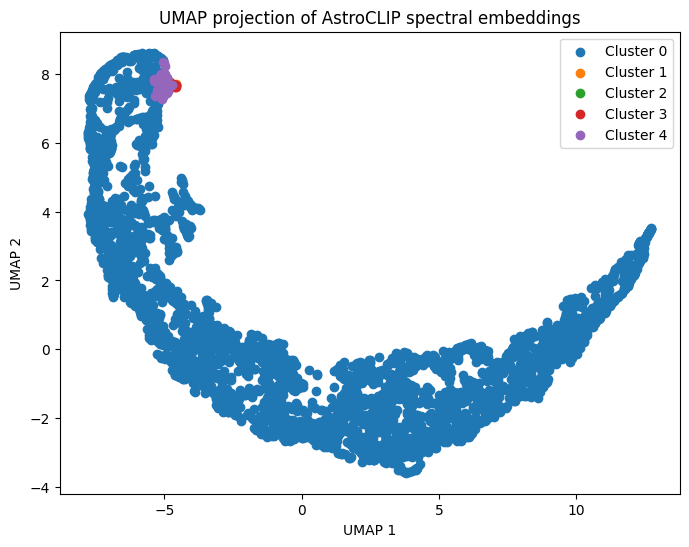

Found 200 anomalies with distance > 0.001


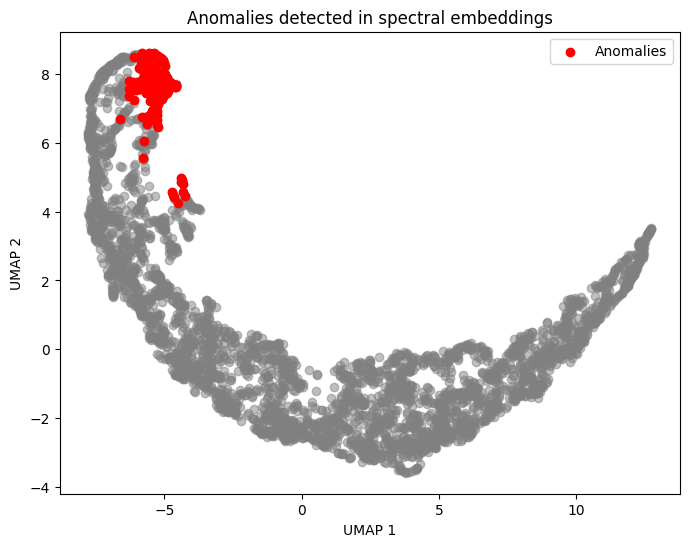

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import umap
from scipy.spatial.distance import cdist

# Assume embeddings is your numpy array or torch tensor of shape (n_samples, embedding_dim)
if hasattr(test_embeddings, 'cpu'):
    emb_np = test_embeddings.cpu().numpy()
else:
    emb_np = test_embeddings

# 1. Clustering in embedding space
k = 5  # Number of clusters, tune as suitable
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(emb_np)

# 2. Visualization with UMAP
reducer = umap.UMAP(random_state=42)
embedding_2d = reducer.fit_transform(emb_np)

plt.figure(figsize=(8, 6))
for cluster_id in range(k):
    cluster_points = embedding_2d[clusters == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {cluster_id}')
plt.legend()
plt.title('UMAP projection of AstroCLIP spectral embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

# 3. Simple Anomaly Detection: distance from closest cluster center
distances = cdist(emb_np, kmeans.cluster_centers_, metric='euclidean')
min_distances = distances.min(axis=1)

# Set a threshold for anomaly (e.g., top 5% farthest)
threshold = np.percentile(min_distances, 95)
anomalies = np.where(min_distances > threshold)[0]

print(f"Found {len(anomalies)} anomalies with distance > {threshold:.3f}")

# Optional: Visualize anomalies on UMAP plot
plt.figure(figsize=(8, 6))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c='gray', alpha=0.5)
plt.scatter(embedding_2d[anomalies, 0], embedding_2d[anomalies, 1], color='red', label='Anomalies')
plt.legend()
plt.title('Anomalies detected in spectral embeddings')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.ensemble import IsolationForest

# Convert embeddings tensor to numpy array if needed
if hasattr(test_embeddings, 'cpu'):
    emb_np = test_embeddings.cpu().numpy()
else:
    emb_np = test_embeddings

# 1. Fit Isolation Forest for anomaly detection
contamination = 0.05  # 5% of data expected to be anomalies, adjust as needed
iso_forest = IsolationForest(contamination=contamination, random_state=42)
iso_forest.fit(emb_np)

# 2. Predict anomalies: -1 is anomaly, 1 is normal
anomaly_labels = iso_forest.predict(emb_np)
anomalies = np.where(anomaly_labels == -1)[0]

# 3. Visualization with UMAP
reducer = umap.UMAP(random_state=42)
embedding_2d = reducer.fit_transform(emb_np)

plt.figure(figsize=(8, 6))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c='gray', alpha=0.5, label='Normal')
plt.scatter(embedding_2d[anomalies, 0], embedding_2d[anomalies, 1], color='red', label='Anomalies')
plt.legend()
plt.title('UMAP projection with Isolation Forest anomaly detection')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

print(f"Found {len(anomalies)} anomalies using Isolation Forest with contamination={contamination}")
